In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from pandas.plotting import parallel_coordinates

In [8]:
# Load the dataset
df = pd.read_csv("./pokemon.csv")

# Display the first few rows of the dataframe
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


- `pd.read_csv("./pokemon.csv")`: This function is called to load the data from a CSV file named pokemon.csv located in the current working directory (./ indicates the current directory). The result is assigned to the variable df, which stands for DataFrame, a common convention in pandas.

- The dataset presumably contains information about Pokémon. The typical data might include columns for Pokémon names, types, stats like HP, Attack, Defense, and so on, but without seeing the actual data, we're assuming based on common Pokémon datasets.

- `df.head()`: This method is used to get a quick overview of the dataset by displaying the first five rows. It's a useful function for quickly checking the structure of your DataFrame, including column names and the types of data in each column

In [9]:
# Displaying the column names of the DataFrame
df.columns

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='object')

- `df.columns`: This line accesses the column names of the DataFrame `df`. The `.columns` attribute of a DataFrame returns an Index object with the column names.

In [10]:
# Get a concise summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

- `df.info()` provides a concise summary of the DataFrame, including the number of entries, the total number of columns, each column's data type, and the number of non-null values.

In [11]:
df.dtypes

abilities             object
against_bug          float64
against_dark         float64
against_dragon       float64
against_electric     float64
against_fairy        float64
against_fight        float64
against_fire         float64
against_flying       float64
against_ghost        float64
against_grass        float64
against_ground       float64
against_ice          float64
against_normal       float64
against_poison       float64
against_psychic      float64
against_rock         float64
against_steel        float64
against_water        float64
attack                 int64
base_egg_steps         int64
base_happiness         int64
base_total             int64
capture_rate          object
classfication         object
defense                int64
experience_growth      int64
height_m             float64
hp                     int64
japanese_name         object
name                  object
percentage_male      float64
pokedex_number         int64
sp_attack              int64
sp_defense    

- `df.dtypes`: This line of code defines the data types of each column in the DataFrame `df`. The `dtypes` attribute of a DataFrame returns a pandas Series where the index is the name of each column, and the corresponding values are the data types of the columns (e.g., `int64`, `float64`, `object` for text, etc.).


In [12]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Displaying the identified numerical and categorical columns
print("Numerical columns:", numerical_cols,"\n")
print("Categorical columns:", categorical_cols)


Numerical columns: Index(['against_bug', 'against_dark', 'against_dragon', 'against_electric',
       'against_fairy', 'against_fight', 'against_fire', 'against_flying',
       'against_ghost', 'against_grass', 'against_ground', 'against_ice',
       'against_normal', 'against_poison', 'against_psychic', 'against_rock',
       'against_steel', 'against_water', 'attack', 'base_egg_steps',
       'base_happiness', 'base_total', 'defense', 'experience_growth',
       'height_m', 'hp', 'percentage_male', 'pokedex_number', 'sp_attack',
       'sp_defense', 'speed', 'weight_kg', 'generation', 'is_legendary'],
      dtype='object') 

Categorical columns: Index(['abilities', 'capture_rate', 'classfication', 'japanese_name', 'name',
       'type1', 'type2'],
      dtype='object')


- To distinguish between categorical and numerical columns in a DataFrame `df`, you can utilize the `select_dtypes` method provided by pandas. This method allows for filtering columns based on their data type.

- And if we require to change the dtype of a column:

```python
# Convert data types if needed
df['Column'] = df['Column'].astype('category')
```

In [13]:
# Counting unique values in each column of the DataFrame
unique_values_count = {col: df[col].nunique() for col in df.columns}

# Displaying the unique value count for each column
for column, n_unique in unique_values_count.items():
    print(f"{column}: {n_unique}")

abilities: 482
against_bug: 5
against_dark: 5
against_dragon: 4
against_electric: 6
against_fairy: 5
against_fight: 6
against_fire: 5
against_flying: 5
against_ghost: 5
against_grass: 5
against_ground: 6
against_ice: 5
against_normal: 4
against_poison: 6
against_psychic: 6
against_rock: 5
against_steel: 5
against_water: 5
attack: 114
base_egg_steps: 10
base_happiness: 6
base_total: 203
capture_rate: 34
classfication: 588
defense: 109
experience_growth: 6
height_m: 51
hp: 99
japanese_name: 801
name: 801
percentage_male: 7
pokedex_number: 801
sp_attack: 111
sp_defense: 97
speed: 113
type1: 18
type2: 18
weight_kg: 421
generation: 7
is_legendary: 2


- To assess the variety within your dataset, counting the unique values in each column provides valuable insights. The following code achieves this by leveraging pandas' `.nunique()` method in a dictionary comprehension

## Data Cleaning

- Depending on the output of `df.info()`, you may need to address missing values, duplicate rows, or incorrect data types.

[Additional Resources Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html)

In [14]:
# Drop duplicates if any
df = df.drop_duplicates()

- `df.drop_duplicates()`: This method scans the DataFrame df for any duplicate rows. A row is considered a duplicate if it has the exact same values in all columns as another row. By default, this method keeps the first occurrence of the duplicated row and removes the subsequent ones.

### How to handle with missing data

[Additional Resources Link](https://www.geeksforgeeks.org/working-with-missing-data-in-pandas/)

In [15]:
# Check for missing values
print(df.isnull().sum())

abilities              0
against_bug            0
against_dark           0
against_dragon         0
against_electric       0
against_fairy          0
against_fight          0
against_fire           0
against_flying         0
against_ghost          0
against_grass          0
against_ground         0
against_ice            0
against_normal         0
against_poison         0
against_psychic        0
against_rock           0
against_steel          0
against_water          0
attack                 0
base_egg_steps         0
base_happiness         0
base_total             0
capture_rate           0
classfication          0
defense                0
experience_growth      0
height_m              20
hp                     0
japanese_name          0
name                   0
percentage_male       98
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
type2                384
weight_kg             20
generation             0


- To check for missing values in the DataFrame `df`, you can use the `.isnull()` method followed by `.sum()`. This combination will provide a count of missing (NaN) values for each column in the DataFrame.

- We observe that `Type 2` column has most of the missing values

In [16]:
# Setting the threshold for missing values
thresh = 10

# Identifying columns with missing values greater than the threshold
na_greater_thresh_features = [col for col in df.columns if df[col].isnull().sum() > thresh]

# Displaying the identified columns
na_greater_thresh_features

['height_m', 'percentage_male', 'type2', 'weight_kg']

- The above code aims to find and list all columns in the DataFrame df that contain a number of missing values greater than a specified threshold value(i.e; Here 10). 
- Sometimes we can replace the above threshold with a percentage.

## For categorical Columns

In [19]:
# Counting the occurrences of each unique value in the 'Type 2' column, including NaN values
value_counts_with_nan = df['type2'].value_counts(dropna=False)

# Displaying the counts
print(value_counts_with_nan)

type2
NaN         384
flying       95
poison       34
ground       34
psychic      29
fairy        29
fighting     25
steel        22
dark         21
grass        20
water        17
dragon       17
ice          15
rock         14
ghost        14
fire         13
electric      9
bug           5
normal        4
Name: count, dtype: int64


- To count how many unique categories exist in the of values in the `Type 2` column, including the count of missing values, you can use the `value_counts` method with the `dropna=False` parameter

[Detailed Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.value_counts.html)

We can either drop the `Nan` values or fill them with our own values

[Detailed Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.fillna.html)

### As `Legendary` column containts 2 unique values with boolean nature we can just use `.astype` to encode 

In [20]:
# Convert boolean column to string type (object)
df['is_legendary'] = df['is_legendary'].astype(int)
df.head()


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


But if you still want to apply the learned Dummy encoding here is a link for understanding
[Detailed Documentation ](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

### As `Type 1` column containts 18 unique values with no inherent ordering between them, Lets apply `One Hot Encoding` on that column to encode.


[Detailed Documentation ](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

In [23]:
pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 4.9 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Initialize the OneHotEncoder
# Note: Use 'sparse_output=False' for newer sklearn versions, 'sparse=False' for older ones.
encoder = OneHotEncoder(sparse_output=False)

# Select the column and access its numpy values
type1_values = df['type1'].values

# Reshape it to be 2D: (-1 means "infer the number of rows", 1 means "1 column")
type1_reshaped = type1_values.reshape(-1, 1)

# CORRECTED LINE: pass 'type1_reshaped' instead of 'types'
one_hot_encoded_types = encoder.fit_transform(type1_reshaped)

# Create a DataFrame with the encoded data
# encoder.categories_[0] contains the unique labels found in the input column
one_hot_encoded_df = pd.DataFrame(one_hot_encoded_types, columns=encoder.categories_[0])

# Display the first few rows
print(one_hot_encoded_df.head())

   bug  dark  dragon  electric  fairy  fighting  fire  flying  ghost  grass  \
0  0.0   0.0     0.0       0.0    0.0       0.0   0.0     0.0    0.0    1.0   
1  0.0   0.0     0.0       0.0    0.0       0.0   0.0     0.0    0.0    1.0   
2  0.0   0.0     0.0       0.0    0.0       0.0   0.0     0.0    0.0    1.0   
3  0.0   0.0     0.0       0.0    0.0       0.0   1.0     0.0    0.0    0.0   
4  0.0   0.0     0.0       0.0    0.0       0.0   1.0     0.0    0.0    0.0   

   ground  ice  normal  poison  psychic  rock  steel  water  
0     0.0  0.0     0.0     0.0      0.0   0.0    0.0    0.0  
1     0.0  0.0     0.0     0.0      0.0   0.0    0.0    0.0  
2     0.0  0.0     0.0     0.0      0.0   0.0    0.0    0.0  
3     0.0  0.0     0.0     0.0      0.0   0.0    0.0    0.0  
4     0.0  0.0     0.0     0.0      0.0   0.0    0.0    0.0  


In [33]:
pip install Jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl (12 kB)

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- STEP 1: PREPARE DATA ---
# (Assuming df is already loaded)
try:
    # Try newer sklearn version
    encoder = OneHotEncoder(sparse_output=False)
except TypeError:
    # Fallback for older sklearn version
    encoder = OneHotEncoder(sparse=False)

# Reshape data
type1_values = df['type1'].values.reshape(-1, 1)
one_hot_encoded_types = encoder.fit_transform(type1_values)
one_hot_encoded_df = pd.DataFrame(one_hot_encoded_types, columns=encoder.categories_[0])

# --- STEP 2: STYLE DATA ---
def highlight_ones(val):
    color = 'green' if val == 1 else 'transparent'
    return f'background-color: {color}'

# Apply style (handles both old and new pandas)
try:
    # Try newer pandas version
    styled_df = one_hot_encoded_df.head().style.map(highlight_ones)
except AttributeError:
    # Fallback for older pandas version
    styled_df = one_hot_encoded_df.head().style.applymap(highlight_ones)

styled_df

,bug,dark,dragon,electric,fairy,fighting,fire,flying,ghost,grass,ground,ice,normal,poison,psychic,rock,steel,water
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Applying One-Hot Encoding Using Sklearn

#### 1. **Importing Necessary Libraries:**
- `from sklearn.preprocessing import OneHotEncoder`: This imports the `OneHotEncoder` class from `sklearn.preprocessing`, which is used for one-hot encoding.
- `import pandas as pd`: Imports the Pandas library for data manipulation.

#### 2. **Loading the Dataset:**
- `data = pd.read_csv(file_path)`: Reads the data from the specified CSV file into a Pandas DataFrame.

#### 3. **Initializing the OneHotEncoder:**
- `encoder = OneHotEncoder(sparse=False)`: Creates an instance of the `OneHotEncoder`. The `sparse=False` argument makes the output an array instead of a sparse matrix, which is easier to work with if memory is not an issue.

#### 4. **Preparing Data for Encoding:**
- `types = data['Type 1'].values.reshape(-1, 1)`: Reshapes the 'Type 1' column to be a 2D array, as `fit_transform` requires input to be in this shape.

#### 5. **Fitting and Transforming the Data:**
- `one_hot_encoded_types = encoder.fit_transform(types)`: This line actually performs the one-hot encoding. The encoder learns the categories and transforms the data into a binary (one-hot encoded) format.

#### 6. **Creating a DataFrame from the Encoded Data:**
- `one_hot_encoded_df = pd.DataFrame(one_hot_encoded_types, columns=encoder.categories_[0])`: Constructs a new DataFrame from the encoded data. Column names are set to the unique categories identified by the encoder in the 'Type 1' column.


This approach using `sklearn` is particularly useful when you want to integrate encoding seamlessly with other preprocessing steps in a machine learning pipeline, maintaining consistency and efficiency.


## For Numerical Columns

In [35]:
# Generating descriptive statistics for numerical columns in the DataFrame
descriptive_stats = df.describe()

# Displaying the descriptive statistics
display(descriptive_stats)

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,height_m,hp,percentage_male,pokedex_number,sp_attack,sp_defense,speed,weight_kg,generation,is_legendary
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,781.000000,801.000000,703.000000,801.000000,801.000000,801.000000,801.000000,781.000000,801.000000,801.000000
mean,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,1.034020,...,1.163892,68.958801,55.155761,401.000000,71.305868,70.911361,66.334582,61.378105,3.690387,0.087391
std,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,0.788896,...,1.080326,26.576015,20.261623,231.373075,32.353826,27.942501,28.907662,109.354766,1.930420,0.282583
min,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,...,0.100000,1.000000,0.000000,1.000000,10.000000,20.000000,5.000000,0.100000,1.000000,0.000000
25%,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,0.500000,...,0.600000,50.000000,50.000000,201.000000,45.000000,50.000000,45.000000,9.000000,2.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,65.000000,50.000000,401.000000,65.000000,66.000000,65.000000,27.300000,4.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.500000,80.000000,50.000000,601.000000,91.000000,90.000000,85.000000,64.800000,5.000000,0.000000
max,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,14.500000,255.000000,100.000000,801.000000,194.000000,230.000000,180.000000,999.900000,7.000000,1.000000


The `df.describe()` method is a convenient way to get a quick overview of the statistical characteristics of the numerical columns in your DataFrame

The output of `df.describe()` includes the following statistics for each numerical column in the DataFrame:

    count: The number of non-missing values.
    mean: The mean of the values.
    std: The standard deviation of the values, which measures the dispersion from the mean.
    min: The minimum value.
    25% (first quartile): The value below which 25% of the data fall.
    50% (median): The middle value, splitting the dataset in half.
    75% (third quartile): The value below which 75% of the data fall.
    max: The maximum value.

Categorical Data: By default, `df.describe()` only analyzes numeric columns. If you want to include categorical data in the analysis, you can use `df.describe(include=['object'])` or `df.describe(include='all')` to include all columns, regardless of data type.




[Detailed Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)

## Visual Exploration 

### 1. Bar Chart 
- Question it answers: Which Pokémon types are the most common?

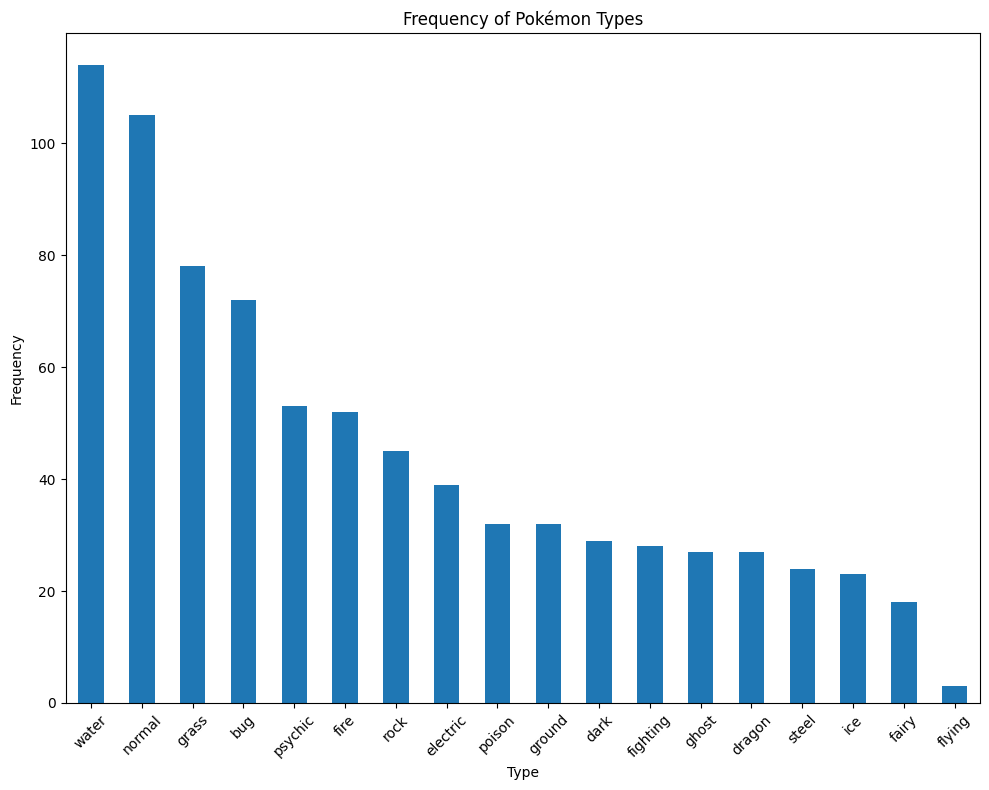

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data (if not already loaded)
df = pd.read_csv('pokemon.csv')

# 1. FIX: Use correct column name 'type1' (lowercase)
type_counts = df['type1'].value_counts()

# 2. Generate the bar chart
# Passing figsize directly to plot() is often cleaner
type_counts.plot(kind='bar', figsize=(10, 8))

plt.title('Frequency of Pokémon Types')
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

# 3. Save or Show the plot
plt.tight_layout()
plt.savefig('pokemon_type_frequency.png') # Using savefig is safer for scripts
plt.show()


Interpretation:
This bar chart displays the distribution of primary Pokémon types in the dataset. Each bar represents a different Pokémon type, and the height of the bar indicates how many Pokémon belong to that type. This visualization helps in understanding which types are the most common and which are rarer.

### 2. Pie Chart 
- Question it answers: What proportion of the Pokémon dataset is made up by each primary type?

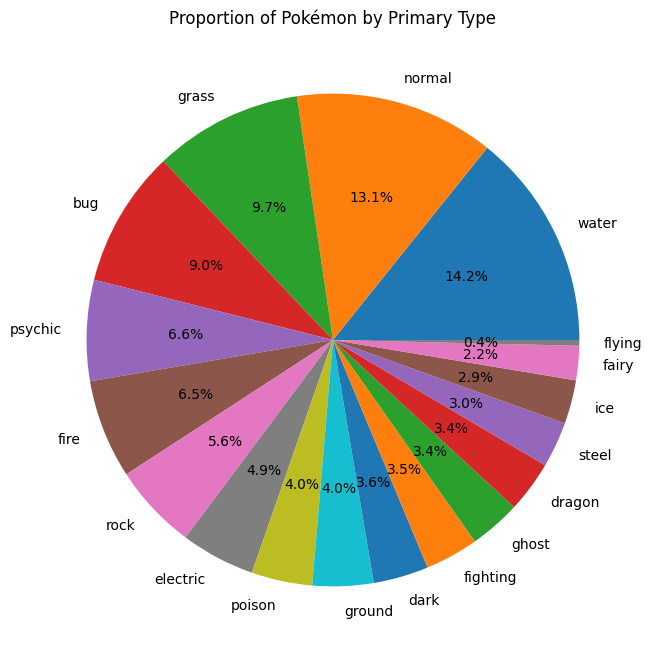

In [38]:
plt.figure(figsize=(10, 8))
type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Pokémon by Primary Type')
plt.ylabel('')  # Hide the 'Type 1' label
plt.show()

Interpretation:
This pie chart illustrates the proportion of the total Pokémon dataset made up by each primary type. The chart visually breaks down the dataset into segments, making it easy to see which types constitute a larger or smaller proportion of the collection.

### 3. Line Graph
- Question it answers: How does the average attack power of Pokémon change across different generations?

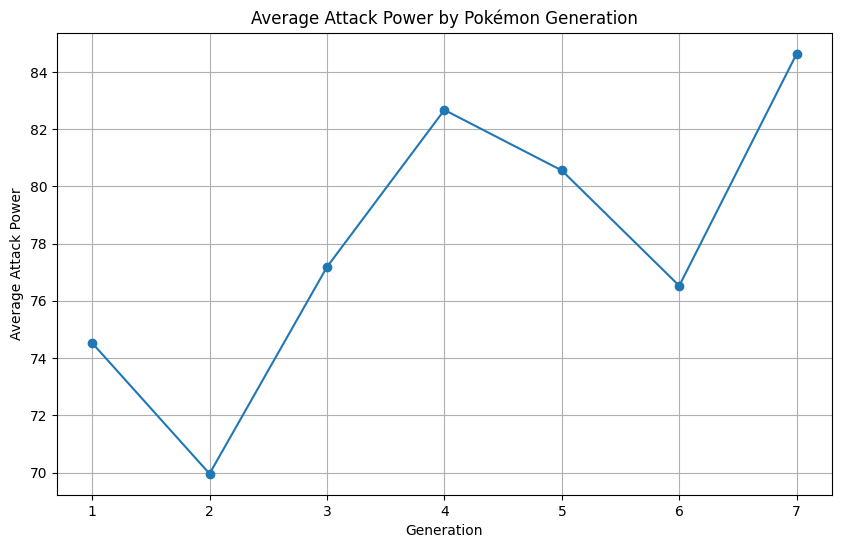

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the average attack by generation
# FIX: Use lowercase 'generation' and 'attack'
avg_attack_by_gen = df.groupby('generation')['attack'].mean()

# Generate the line graph
plt.figure(figsize=(10, 6))
avg_attack_by_gen.plot(kind='line', marker='o')

plt.title('Average Attack Power by Pokémon Generation')
plt.xlabel('Generation')
plt.ylabel('Average Attack Power')
plt.grid(True)
plt.xticks(avg_attack_by_gen.index)

plt.savefig('avg_attack_by_generation.png')
plt.show()

Interpretation:
This line graph displays the trend in average attack power of Pokémon across different generations. Each point on the line represents the average attack power for a generation, providing insights into how combat capabilities have evolved over time.

### 4. Scatter Plot
- Question it answers: How does the relationship between Attack and Defense differ between Legendary and Non-Legendary Pokémon?

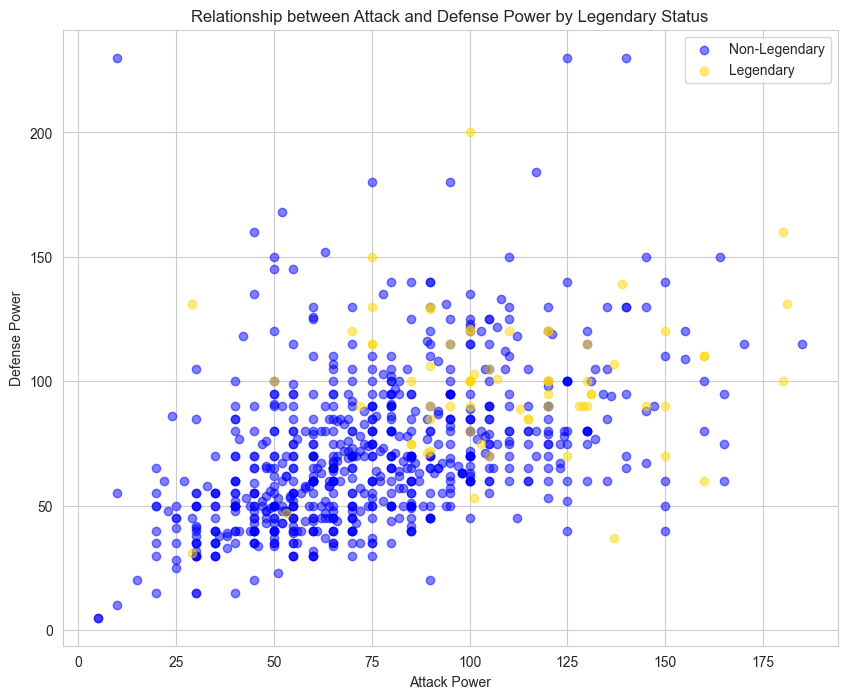

In [41]:
import seaborn as sns
import pandas as pd

# Load the data (if not already loaded)
df = pd.read_csv('pokemon.csv')

# Set the aesthetic style
sns.set_style("whitegrid")

plt.figure(figsize=(10, 8))

# FIX 1: Use 'is_legendary' instead of 'Legendary'
# FIX 2: Use 0/1 instead of False/True (though False/True often works with 0/1, being explicit is safer)
# FIX 3: Use lowercase 'attack' and 'defense'
non_legendary = df[df['is_legendary'] == 0]
plt.scatter(non_legendary['attack'], non_legendary['defense'], alpha=0.5, color='blue', label='Non-Legendary')

legendary = df[df['is_legendary'] == 1]
plt.scatter(legendary['attack'], legendary['defense'], alpha=0.5, color='gold', label='Legendary')

plt.title('Relationship between Attack and Defense Power by Legendary Status')
plt.xlabel('Attack Power')
plt.ylabel('Defense Power')
plt.legend()
plt.grid(True)
plt.show()


The scatter plot displays the relationship between Attack and Defense powers for Pokémon, categorized by their Legendary status. 
Points are colored differently—blue for Non-Legendary Pokémon and gold for Legendary Pokémon—allowing us to observe any distinct patterns or clusters. 

We observe that, All Legendary Pokémon have moderate to high attach power and defence stats compared to Non-Legendary Pokémon, indicating their generally superior combat capabilities.

### 5. Pair Plot
- Question it answers: How do multiple attributes (such as HP, Attack, Defense, and Speed) relate to each other across Pokémon?

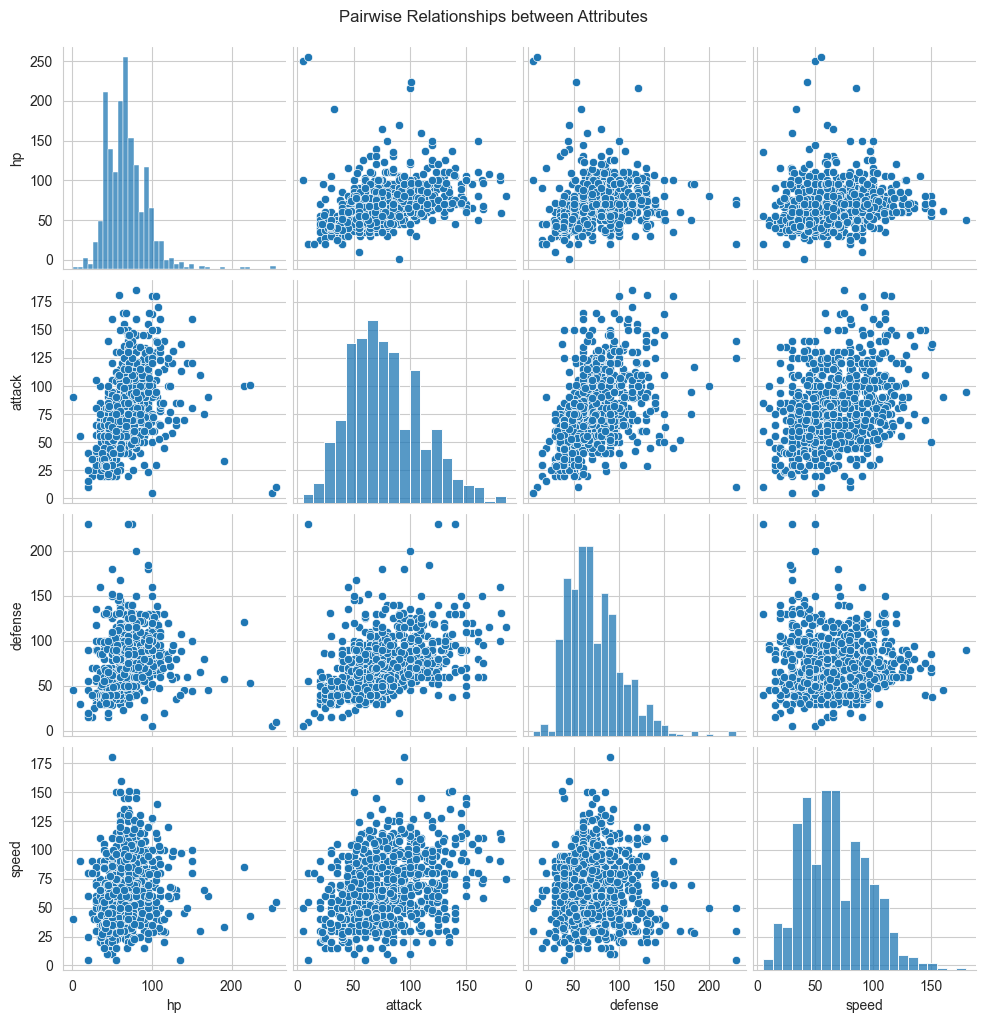

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a subset of columns for the pair plot
# FIX: Use lowercase column names to match the dataset
attributes = ['hp', 'attack', 'defense', 'speed']

sns.pairplot(df[attributes])
plt.suptitle('Pairwise Relationships between Attributes', y=1.02)
plt.show()

Interpretation:
A pair plot provides a comprehensive overview of how several key attributes relate to each other across all Pokémon in the dataset. Each plot in the matrix shows the relationship between two attributes, with histograms on the diagonal providing the distribution of a single attribute.

### 6. Radar Chart
- Question it answers: How do the attributes (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed) of Pikachu and Bulbasaur compare with each other?

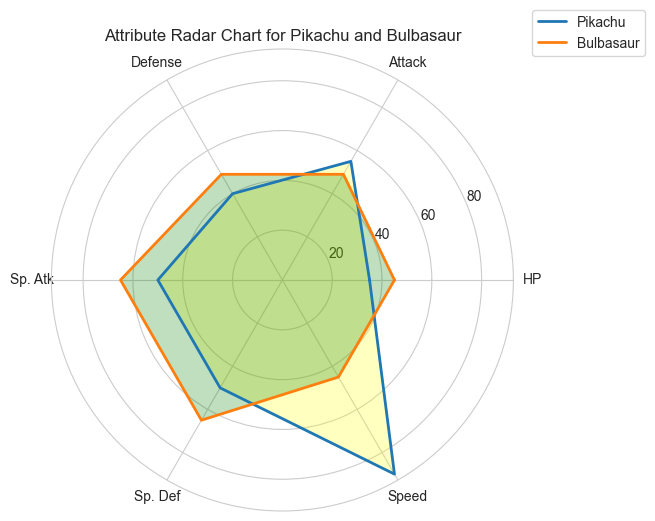

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data (assuming it's already loaded, but including for completeness)
df = pd.read_csv('pokemon.csv')

# Select two Pokémon for comparison
# FIX: Use correct lowercase column names from the dataframe
pikachu_stats = df.loc[df['name'] == 'Pikachu', ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].values.flatten().tolist()
bulbasaur_stats = df.loc[df['name'] == 'Bulbasaur', ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].values.flatten().tolist()

# Attributes to compare (Labels for the chart can stay nice and capitalized)
categories = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Calculate angles for radar chart
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

# Data needs to be repeated at the end to close the radar chart
pikachu_stats += pikachu_stats[:1]
bulbasaur_stats += bulbasaur_stats[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, pikachu_stats, linewidth=2, linestyle='solid', label='Pikachu')
ax.fill(angles, pikachu_stats, color='yellow', alpha=0.25)

ax.plot(angles, bulbasaur_stats, linewidth=2, linestyle='solid', label='Bulbasaur')
ax.fill(angles, bulbasaur_stats, color='green', alpha=0.25)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# Adjust legend position slightly to avoid overlap
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.title('Attribute Radar Chart for Pikachu and Bulbasaur')
plt.show()

Interpretation:

This radar chart provides a visual comparison of key attributes for Pikachu and Bulbasaur. Each spoke of the radar represents one of the attributes: HP, Attack, Defense, Sp. Atk, Sp. Def, and Speed. 

The chart enables you to visually assess the strengths and weaknesses of these two Pokémon:

    - Pikachu typically excels in Speed but may have lower HP and Defense.
    - Bulbasaur might demonstrate more balanced attributes, particularly with higher HP and Defense, which could make it more resilient in battle scenarios.

### 7. Parallel Coordinate Plot
- Question it answers: How do several selected Pokémon compare across multiple attributes (such as HP, Attack, Defense, and Speed)?

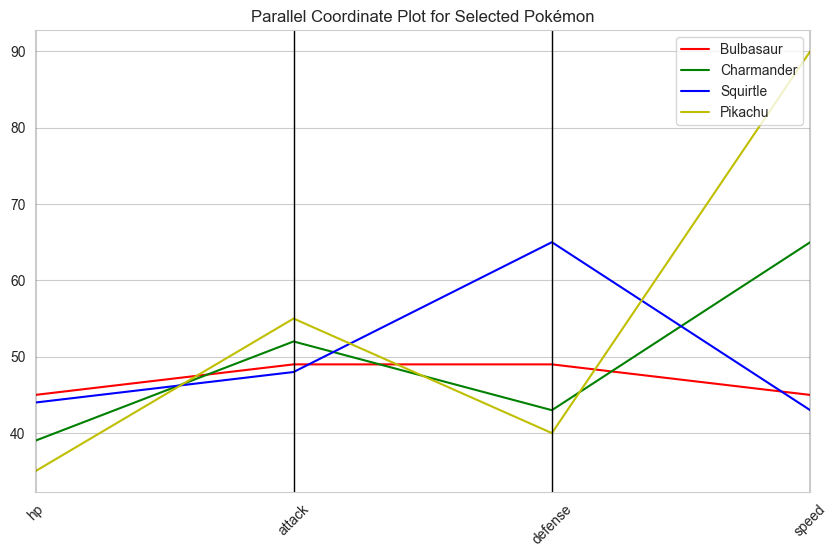

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Load the dataframe (if not already loaded)
df = pd.read_csv('pokemon.csv')

# Select a few Pokémon for comparison
# FIX: Use 'name' instead of 'Name'
selected_pokemon = df[df['name'].isin(['Pikachu', 'Charmander', 'Bulbasaur', 'Squirtle'])]

# Generate the parallel coordinate plot
plt.figure(figsize=(10, 6))

# FIX: Use lowercase column names for 'name' and the attributes
parallel_coordinates(
    selected_pokemon, 
    'name', 
    cols=['hp', 'attack', 'defense', 'speed'], 
    color=['r', 'g', 'b', 'y']
)

plt.title('Parallel Coordinate Plot for Selected Pokémon')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Interpretation:
A parallel coordinate plot allows for the comparison of selected Pokémon across multiple attributes simultaneously. Each line represents a Pokémon, with intersections on the attribute axes indicating the Pokémon's scores in those attributes. This visualization is useful for comparing the attributes of multiple Pokémon at once.

### 8. Sankey Diagram
- Question it answers: How do type transitions in Pokémon differ when considering Legendary versus Non-Legendary Pokémon, and what are the most common type transitions for each group?

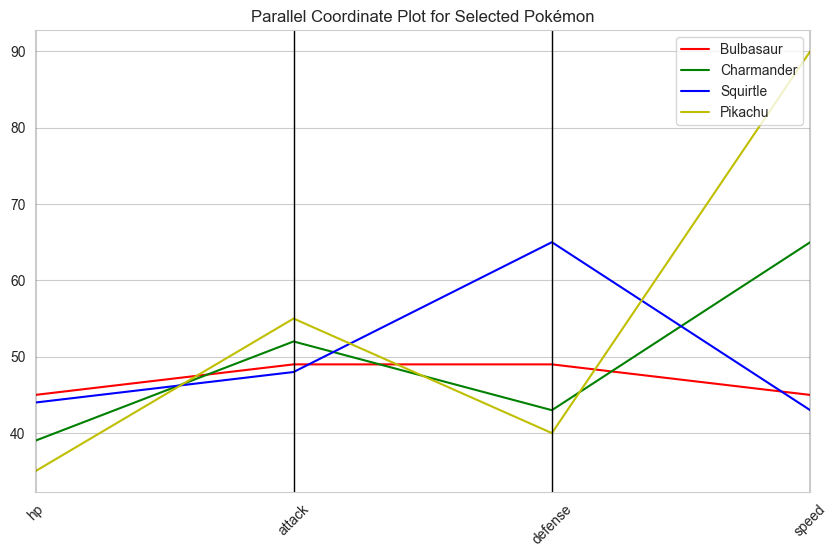

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Load the dataframe
df = pd.read_csv('pokemon.csv')

# Select a few Pokémon for comparison
selected_pokemon = df[df['name'].isin(['Pikachu', 'Charmander', 'Bulbasaur', 'Squirtle'])]

# Generate the parallel coordinate plot
plt.figure(figsize=(10, 6))

parallel_coordinates(
    selected_pokemon, 
    'name', 
    cols=['hp', 'attack', 'defense', 'speed'], 
    color=['r', 'g', 'b', 'y']
)

plt.title('Parallel Coordinate Plot for Selected Pokémon')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Updated Interpretation:

This Sankey diagram will now visually separate the flows of Pokémon type transitions based on the proportion of times they involve Legendary versus Non-Legendary Pokémon. By categorizing the links using different colors:

    Orange: Transitions predominantly involving Legendary Pokémon, indicating rarer or more specialized type combinations.
    Light Blue: Transitions primarily involving Non-Legendary Pokémon, showcasing common or standard type transitions in the Pokémon universe.

### 9. Histogram
- Question it answers: What is the distribution of Pokémon by their Speed attribute?

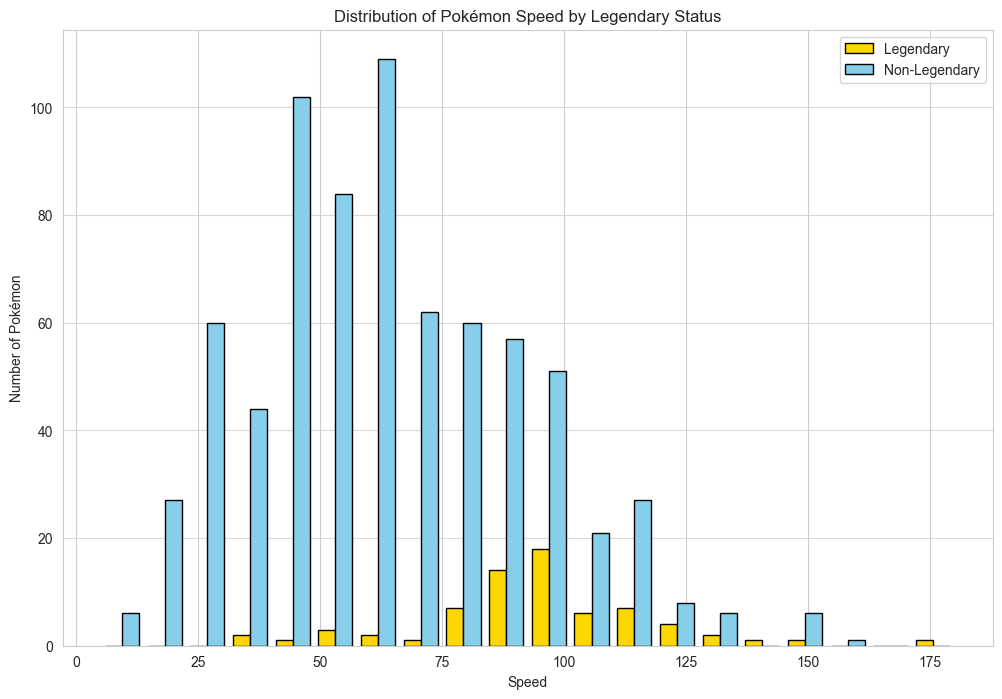

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataframe
df = pd.read_csv('pokemon.csv')

plt.figure(figsize=(12, 8))

# Separate the data into legendary and non-legendary for comparison
# FIX 1: Use 'is_legendary' instead of 'Legendary'
# FIX 2: Use 'speed' instead of 'Speed'
legendary = df[df['is_legendary'] == 1]['speed']
non_legendary = df[df['is_legendary'] == 0]['speed']

# Plot histograms for both legendary and non-legendary Pokémon
plt.hist([legendary, non_legendary], bins=20, color=['gold', 'skyblue'], edgecolor='black', label=['Legendary', 'Non-Legendary'])

plt.title('Distribution of Pokémon Speed by Legendary Status')
plt.xlabel('Speed')
plt.ylabel('Number of Pokémon')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Interpretation:
The histogram illustrates the distribution of Pokémon based on their Speed attribute. Each bin represents a range of Speed values, and the height of each bin indicates the number of Pokémon falling within that range. This visualization helps to understand the overall spread of Speed values across the dataset, showing whether most Pokémon are fast, slow, or somewhere in between.

### 10. Box Plot
- Question it answers: What is the variation in HP among Pokémon, and are there any outliers, especially when comparing Legendary to Non-Legendary Pokémon?

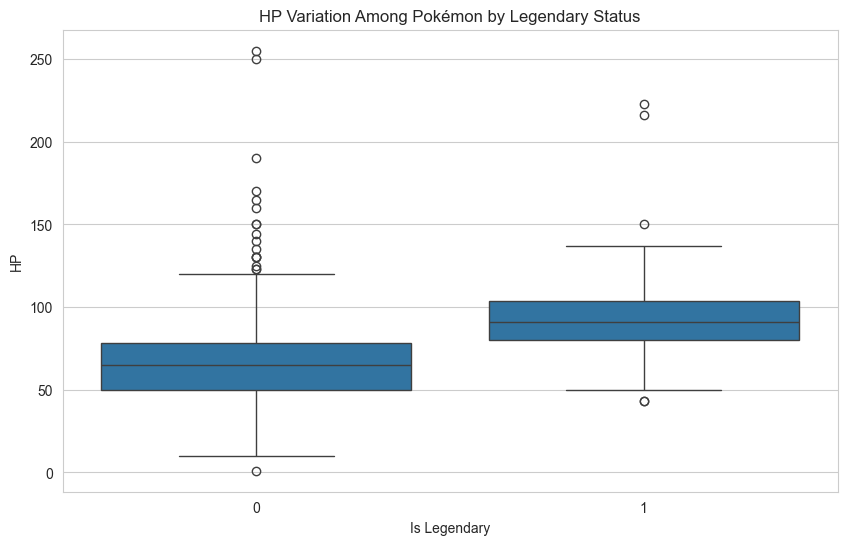

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# FIX 1: Use 'is_legendary' instead of 'Legendary'
# FIX 2: Use 'hp' instead of 'HP'
sns.boxplot(x='is_legendary', y='hp', data=df)

plt.title('HP Variation Among Pokémon by Legendary Status')
plt.xlabel('Is Legendary')
plt.ylabel('HP')
plt.show()

Interpretation:
A box plot for HP among Pokémon can highlight the median, quartiles, and outliers within the data, comparing legendary to non-legendary Pokémon. This visualization is useful for understanding the spread and central tendency of HP values, as well as identifying any Pokémon with unusually high or low HP.

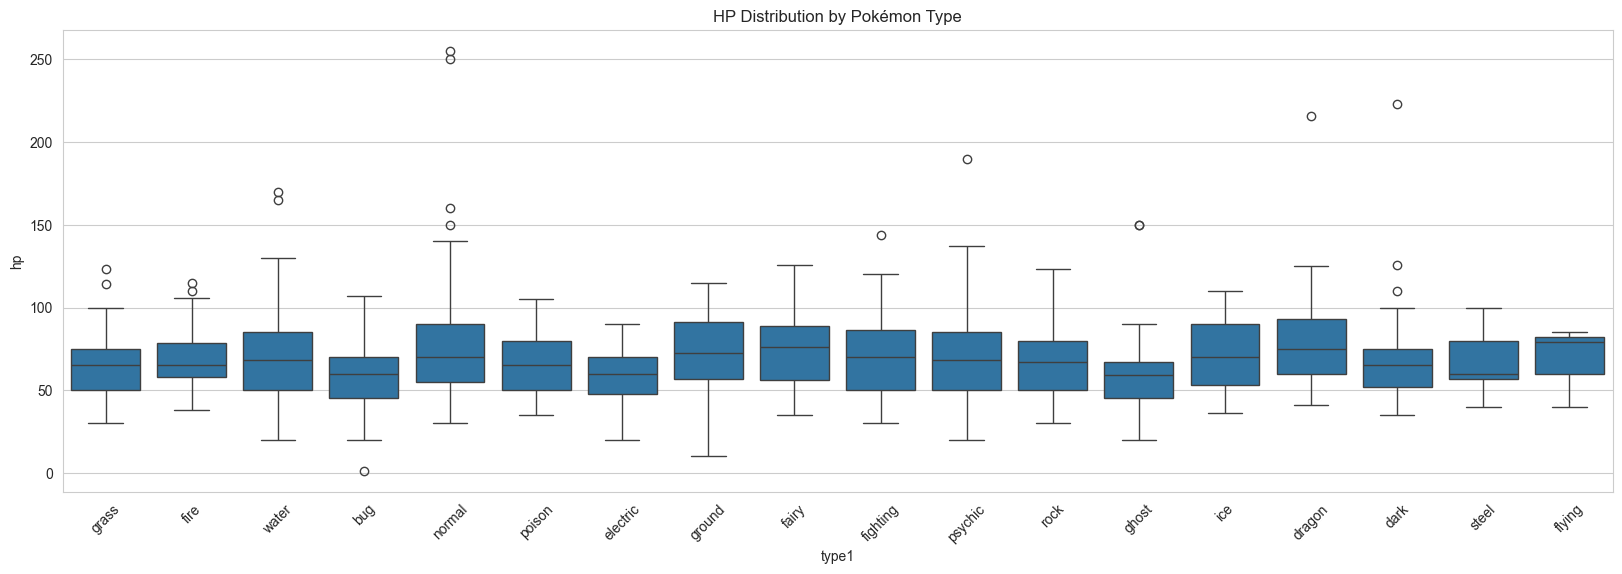

In [54]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))

# FIX 1: Use 'type1' instead of 'Type 1'
# FIX 2: Use 'hp' instead of 'HP'
sns.boxplot(x='type1', y='hp', data=df)

plt.title('HP Distribution by Pokémon Type')

# OPTIONAL FIX: Rotate the labels so they don't overlap
plt.xticks(rotation=45)

plt.show()

- The above box plot shows the distribution of the "HP" (Hit Points) variable for each Pokémon type (categorized under "Type 1")

### 11. Violin Chart
- Question it answers: How does the distribution of Attack values differ between Legendary and Non-Legendary Pokémon, including the density of data points?

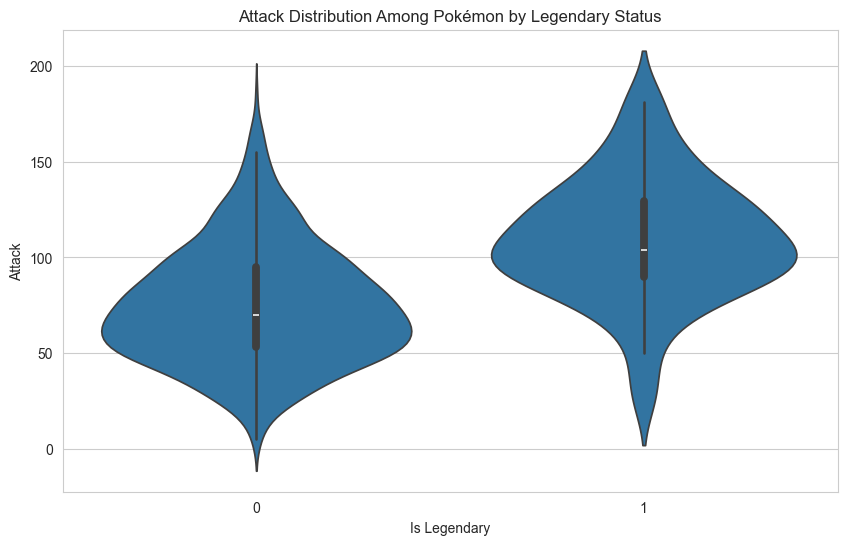

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# FIX 1: Use 'is_legendary' instead of 'Legendary'
# FIX 2: Use 'attack' instead of 'Attack'
sns.violinplot(x='is_legendary', y='attack', data=df)

plt.title('Attack Distribution Among Pokémon by Legendary Status')
plt.xlabel('Is Legendary')
plt.ylabel('Attack')
plt.show()


Interpretation:
The violin plot combines aspects of box plots with a kernel density estimation to show the distribution of Attack values for both Legendary and Non-Legendary Pokémon. This visualization provides insight into the central tendency, dispersion, and density of Attack values, highlighting how they differ between Legendary and Non-Legendary Pokémon. It's especially useful for seeing the distribution shape and any potential multimodality in the data.

### 12. Area Plot
- Question it answers: How does the average Speed of Legendary versus Non-Legendary Pokémon vary across different types, and what does this indicate about their strategic roles in battles?

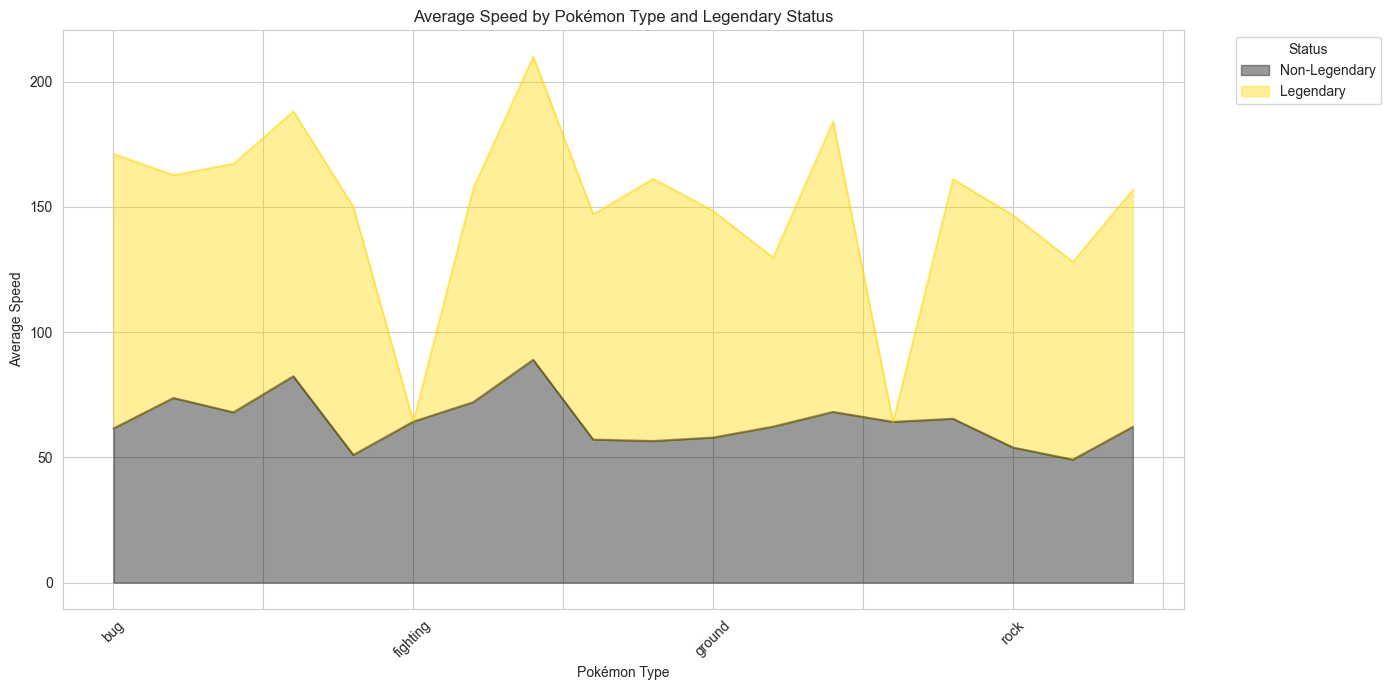

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataframe
df = pd.read_csv('pokemon.csv')

# 1. FIX: Use lowercase column names for stats
stats_columns = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

# Ensure 'total' is calculated using correct column names
# (Note: The dataset likely already has 'base_total', but here is the manual calculation fix)
df['total'] = df[stats_columns].sum(axis=1)

# 2. FIX: Use 'type1' and 'is_legendary' (lowercase)
# 'speed' is also lowercase
avg_speed_by_type_legendary = df.groupby(['type1', 'is_legendary'])['speed'].mean().unstack()

# Rename the columns (0 and 1) to meaningful names for the legend
avg_speed_by_type_legendary.columns = ['Non-Legendary', 'Legendary']

# Colors for the plot
colors = ['black', 'gold'] 

# Generate the area plot
plt.figure(figsize=(14, 7))

# Pass the axes to plot on the current figure
avg_speed_by_type_legendary.plot(kind='area', alpha=0.4, color=colors, ax=plt.gca())

plt.title('Average Speed by Pokémon Type and Legendary Status')
plt.xlabel('Pokémon Type')
plt.ylabel('Average Speed')
plt.xticks(rotation=45) 

# 3. FIX: syntax error in legend. Removed the floating list outside the function.
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", title='Status')

plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation:

This area chart provides a visual comparison of the average Speed between Legendary and Non-Legendary Pokémon across different types:

- Visual Differentiation: Each type's average Speed is now split into two layers, one for Legendary and one for Non-Legendary Pokémon, showing how Speed varies within types based on their Legendary status.
    
- Strategic Roles and Game Balancing:
        Legendary Pokémon often have higher Speeds, which may correspond with their roles as game changers in battles, equipped to strike first and make impactful moves.
        Non-Legendary Pokémon may exhibit a broader range of Speeds, reflecting their varied roles in the Pokémon ecosystem from starters to regular battle contenders.

### 13. Bubble Chart
- Question it answers: How does the Attack power of Pokémon vary with their Defense power, weighted by their Total stats?

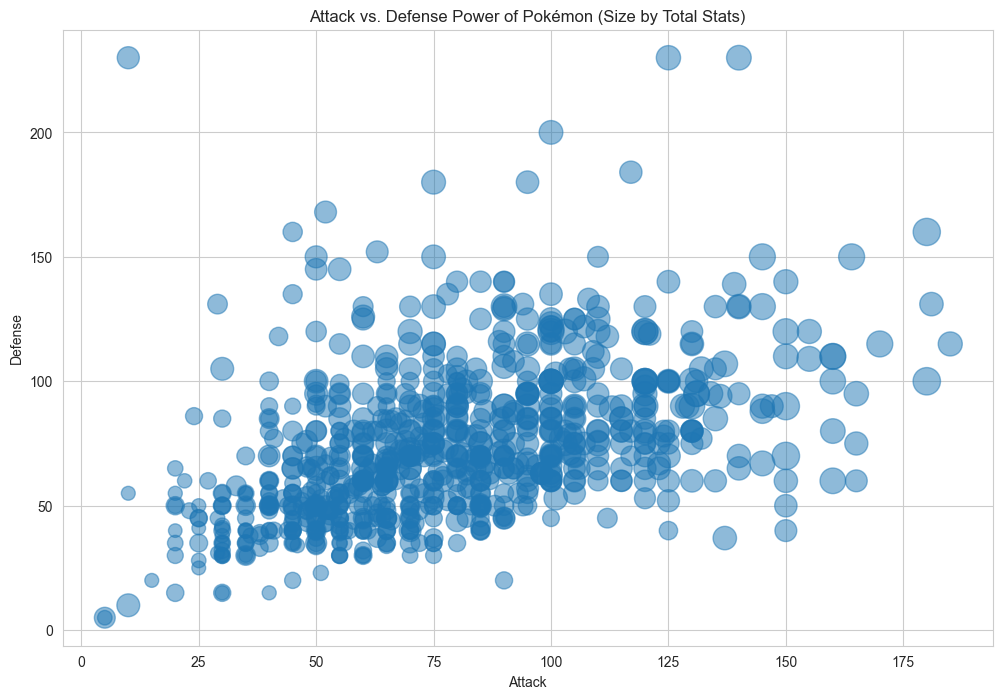

In [60]:


# Load the dataframe
df = pd.read_csv('pokemon.csv')

plt.figure(figsize=(12, 8))

# FIX 1: Use correct column name 'base_total'
# Optional: Multiply by a factor (e.g. 0.5) to adjust bubble size if they are too big
bubble_sizes = df['base_total'] * 0.5

# FIX 2: Use lowercase 'attack' and 'defense'
plt.scatter(df['attack'], df['defense'], s=bubble_sizes, alpha=0.5)

plt.title('Attack vs. Defense Power of Pokémon (Size by Total Stats)')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.grid(True)
plt.show()

Interpretation:
This bubble chart plots Pokémon Attack against Defense power, where the size of each bubble represents the Pokémon's Total stats. It visually demonstrates not just the relationship between Attack and Defense but also gives an indication of the overall strength (Total stats) of the Pokémon.

### 14. Heat Maps
- Question it answers: How are different stats (like HP, Attack, Defense, etc.) correlated with each other among Pokémon?

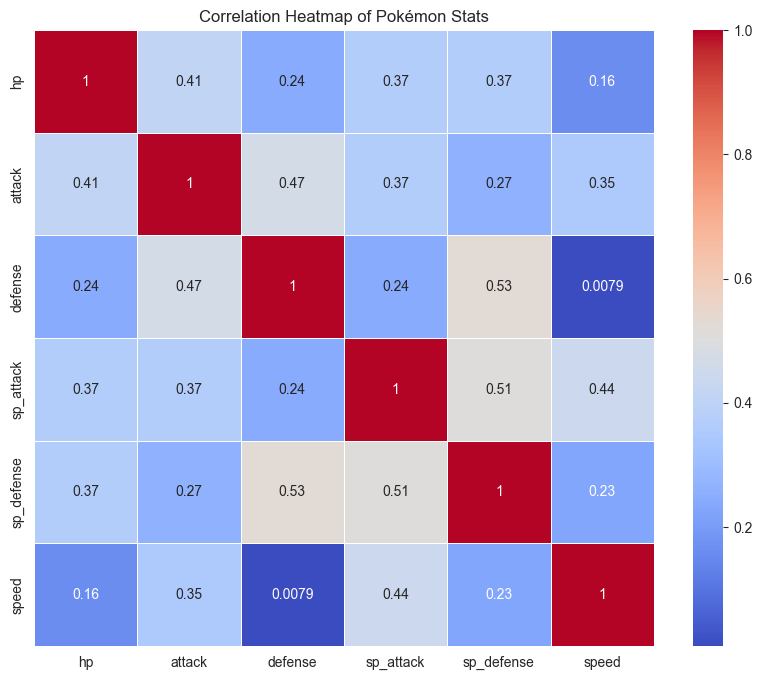

In [61]:
corr_matrix = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].corr()

# Generate the heat map
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Pokémon Stats')
plt.show()


Interpretation:
A heat map of the correlation matrix visually represents the relationship between different Pokémon stats. Each cell in the heat map shows the correlation coefficient between two stats, with color intensity indicating the strength and direction of the correlation (red for positive, blue for negative). This visualization helps in identifying which stats tend to increase or decrease together, indicating potential trends or patterns in Pokémon attributes.

### 15. Tree Maps
- Question it answers: How is the total number of Pokémon distributed among the various primary types, further divided by their Legendary status?

In [76]:
import plotly.express as px

df_tree_map = df.copy()
# Fix columns and map values
df_tree_map['is_legendary'] = df_tree_map['is_legendary'].map({1: 'Legendary', 0: 'Non-Legendary'})

# Create treemap using the path hierarchy
fig = px.treemap(
    df_tree_map, 
    path=[px.Constant("All Pokémon"), 'type1', 'is_legendary'], 
    title='Tree Map of Pokémon by Primary Type and Legendary Status'
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Interpretation:
This tree map divides the space into areas corresponding to the number of Pokémon in each primary type, making it easy to compare the relative frequencies at a glance. The size of each area is proportional to the count of Pokémon in that type, providing a visual representation of type distribution.

### 16. Network Graphs
- Question it answers: How are Pokémon types connected based on dual-type combinations, and what is the proportion of Legendary Pokémon within each type?

In [67]:
pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [73]:
pip install ipython


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [71]:
pip install nbformat

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (4.1 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
Using cached rpds_py-0.30.0-cp313-cp313-macosx_11_0_arm64.whl (358 kB)

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To upda

In [75]:
import plotly.graph_objects as go
import networkx as nx
import pandas as pd

# Load data
df = pd.read_csv('pokemon.csv')

# Create the graph
G = nx.Graph()

# Calculate proportion (Ensure data is numeric first)
type_legendary_proportion = df.groupby('type1')['is_legendary'].mean().to_dict()

# Add nodes
all_types = pd.concat([df['type1'], df['type2'].dropna()]).unique()
for pokemon_type in all_types:
    prop = type_legendary_proportion.get(pokemon_type, 0)
    G.add_node(pokemon_type, legendary_proportion=prop)

# Add edges
for _, row in df.dropna(subset=['type2']).iterrows():
    G.add_edge(row['type1'], row['type2'])

# Position nodes
pos = nx.spring_layout(G, seed=42, k=0.5)

# Create Node Trace
node_trace = go.Scatter(
    x=[pos[node][0] for node in G.nodes()],
    y=[pos[node][1] for node in G.nodes()],
    text=[node for node in G.nodes()],
    mode='markers+text',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        color=[G.nodes[node]['legendary_proportion'] for node in G.nodes()],
        size=25,
        colorbar=dict(
            thickness=15,
            # Corrected title structure
            title=dict(
                text='Legendary %',
                side='right'
            ),
            xanchor='left'
        ),
        line_width=2
    ),
    textposition="top center",
    textfont=dict(size=12, color='black')
)

# Create Edge Trace
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, 
    y=edge_y, 
    line=dict(width=1, color='#888'), 
    hoverinfo='none', 
    mode='lines'
)

# Render
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Network Graph of Pokémon Types',
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20, l=5, r=5, t=40),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                ))

# CHANGED: Save to file instead of showing directly
fig.write_html("pokemon_network_graph.html")
print("Interactive graph saved as 'pokemon_network_graph.html'. Open this file in your browser to view it.")

Interactive graph saved as 'pokemon_network_graph.html'. Open this file in your browser to view it.
